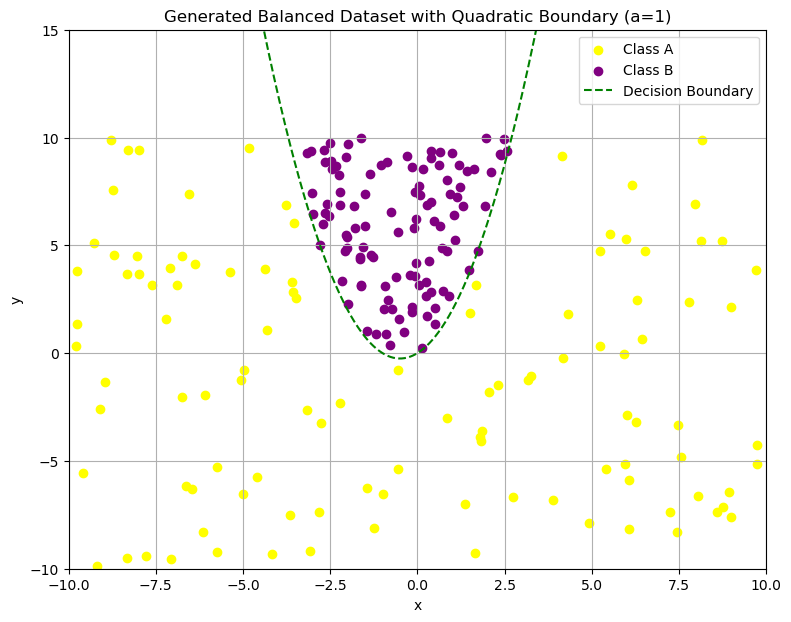

In [30]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score

def generate_balanced_dataset(a, num_points=1000):
    np.random.seed(42)  # For reproducibility
    x = np.random.uniform(-10, 10, num_points)
    y = np.random.uniform(-10, 10, num_points)

    # Calculate the boundary
    y_boundary = a * x**2 + x

    # Classify points
    labels = np.where(y > y_boundary, 1, 0)

    # Count how many points belong to each class
    class_1_indices = np.where(labels == 1)[0]
    class_0_indices = np.where(labels == 0)[0]

    # To balance, we need the same number of points in each class
    num_class_0 = len(class_0_indices)
    num_class_1 = len(class_1_indices)

    # Select the smaller class size
    num_samples = min(num_class_0, num_class_1)

    # Randomly select an equal number of points from each class
    selected_class_0 = np.random.choice(class_0_indices, num_samples, replace=False)
    selected_class_1 = np.random.choice(class_1_indices, num_samples, replace=False)

    selected_indices = np.concatenate([selected_class_0, selected_class_1])
    np.random.shuffle(selected_indices)

    # Create the balanced dataset
    x_balanced = x[selected_indices]
    y_balanced = y[selected_indices]
    labels_balanced = labels[selected_indices]

    return x_balanced, y_balanced, labels_balanced

# Generate a balanced dataset with a=1
a_value = 1
x, y, labels = generate_balanced_dataset(a=a_value, num_points=1000)

# Plot the dataset with decision boundary
plt.figure(figsize=(9, 7))
plt.scatter(x[labels == 0], y[labels == 0], color='yellow', label='Class A')
plt.scatter(x[labels == 1], y[labels == 1], color='purple', label='Class B')

# Generate points for the quadratic boundary line
x_boundary = np.linspace(-10, 10, 1000)
y_boundary = a_value * x_boundary**2 + x_boundary

# Plot the boundary line
plt.plot(x_boundary, y_boundary, color='green', linestyle='--', label='Decision Boundary')

plt.title(f'Generated Balanced Dataset with Quadratic Boundary (a={a_value})')
plt.xlabel('x')
plt.ylabel('y')
plt.xlim(-10, 10)
plt.ylim(-10, 15)  # Adjust as needed to show both data and boundary
plt.grid(True)
plt.legend()
plt.show()


For a = -0.2:
  Logistic Regression Accuracy: 0.8598
  Neural Network Accuracy: 0.9634

For a = -0.1:
  Logistic Regression Accuracy: 0.9048
  Neural Network Accuracy: 0.9857

For a = 0.1:
  Logistic Regression Accuracy: 0.9170
  Neural Network Accuracy: 0.9869

For a = 0.2:
  Logistic Regression Accuracy: 0.8636
  Neural Network Accuracy: 0.9602

For a = 1:
  Logistic Regression Accuracy: 0.7727
  Neural Network Accuracy: 0.9697



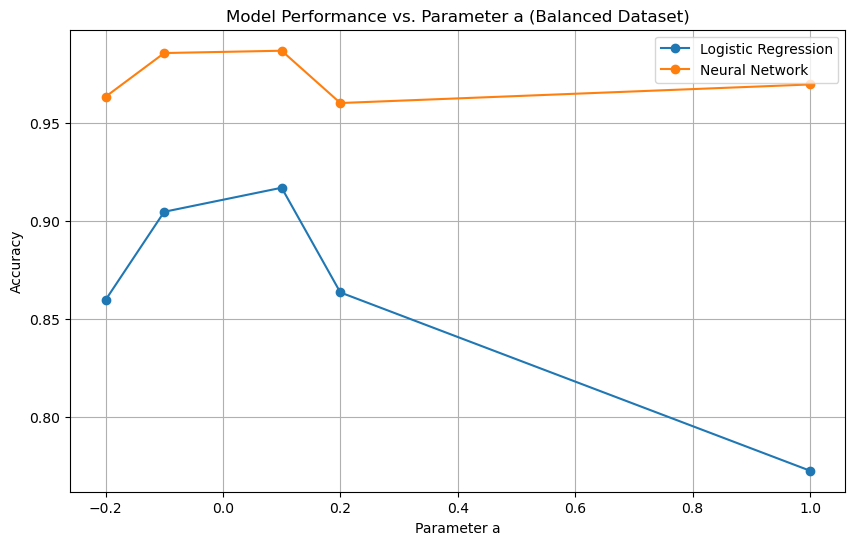

In [42]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score

# Updated balanced dataset generator
def generate_balanced_dataset(a, num_points=1000):
    np.random.seed(42)  # For reproducibility
    x = np.random.uniform(-10, 10, num_points)
    y = np.random.uniform(-10, 10, num_points)

    # Calculate the boundary
    y_boundary = a * x**2 + x

    # Classify points
    labels = np.where(y > y_boundary, 1, 0)

    # Count how many points belong to each class
    class_1_indices = np.where(labels == 1)[0]
    class_0_indices = np.where(labels == 0)[0]

    # To balance, we need the same number of points in each class
    num_class_0 = len(class_0_indices)
    num_class_1 = len(class_1_indices)

    # Select the smaller class size
    num_samples = min(num_class_0, num_class_1)

    # Randomly select an equal number of points from each class
    selected_class_0 = np.random.choice(class_0_indices, num_samples, replace=False)
    selected_class_1 = np.random.choice(class_1_indices, num_samples, replace=False)

    selected_indices = np.concatenate([selected_class_0, selected_class_1])
    np.random.shuffle(selected_indices)

    # Create the balanced dataset
    x_balanced = x[selected_indices]
    y_balanced = y[selected_indices]
    labels_balanced = labels[selected_indices]

    return x_balanced, y_balanced, labels_balanced


# Evaluation function with balanced datasets
def evaluate_with_different_a_values(a_values):
    logistic_accuracies = []
    neural_net_accuracies = []

    for a in a_values:
        # Use the balanced dataset generation function
        x, y, labels = generate_balanced_dataset(a=a, num_points=1000)
        X = np.column_stack((x, y))  # Combine x and y into the feature matrix
        X_train, X_test, y_train, y_test = train_test_split(X, labels, test_size=0.3, random_state=42)

        # Logistic Regression
        log_reg = LogisticRegression()
        log_reg.fit(X_train, y_train)
        log_reg_predictions = log_reg.predict(X_test)
        log_acc = accuracy_score(y_test, log_reg_predictions)
        logistic_accuracies.append(log_acc)

        # Neural Network
        mlp = MLPClassifier(hidden_layer_sizes=(10,), max_iter=2000, random_state=42)
        mlp.fit(X_train, y_train)
        mlp_predictions = mlp.predict(X_test)
        nn_acc = accuracy_score(y_test, mlp_predictions)
        neural_net_accuracies.append(nn_acc)

        print(f"For a = {a}:")
        print(f"  Logistic Regression Accuracy: {log_acc:.4f}")
        print(f"  Neural Network Accuracy: {nn_acc:.4f}")
        print()

    return logistic_accuracies, neural_net_accuracies


# Define the different values of 'a' to evaluate
a_values = [-0.2, -0.1, 0.1, 0.2, 1]

# Run the evaluation with different 'a' values
logistic_accuracies, neural_net_accuracies = evaluate_with_different_a_values(a_values)

# Plot the results
plt.style.use('default')
plt.figure(figsize=(10, 6))
plt.plot(a_values, logistic_accuracies, 'o-', label='Logistic Regression')
plt.plot(a_values, neural_net_accuracies, 'o-', label='Neural Network')
plt.xlabel('Parameter a')
plt.ylabel('Accuracy')
plt.title('Model Performance vs. Parameter a (Balanced Dataset)')
plt.legend()
plt.grid(True)
plt.show()


For dataset size = 100:
Logistic Regression Accuracy: 1.0000
Neural Network Accuracy: 1.0000

For dataset size = 500:
Logistic Regression Accuracy: 0.7778
Neural Network Accuracy: 0.9722

For dataset size = 900:
Logistic Regression Accuracy: 0.7344
Neural Network Accuracy: 1.0000

For dataset size = 1300:
Logistic Regression Accuracy: 0.8395
Neural Network Accuracy: 0.9877



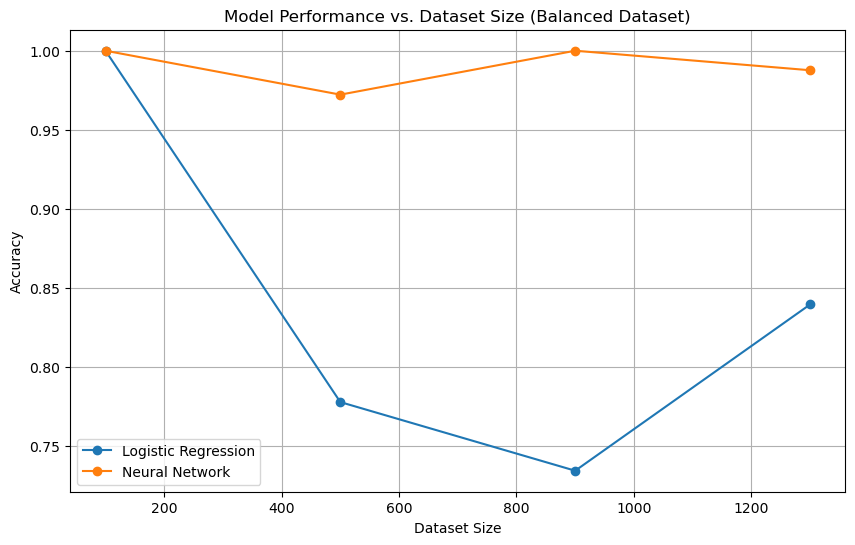

In [34]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score

# Balanced dataset generator
def generate_balanced_dataset(a, num_points=1000):
    np.random.seed(42)  # For reproducibility
    x = np.random.uniform(-10, 10, num_points)
    y = np.random.uniform(-10, 10, num_points)

    # Calculate the boundary
    y_boundary = a * x**2 + x

    # Classify points
    labels = np.where(y > y_boundary, 1, 0)

    # Count how many points belong to each class
    class_1_indices = np.where(labels == 1)[0]
    class_0_indices = np.where(labels == 0)[0]

    # To balance, we need the same number of points in each class
    num_class_0 = len(class_0_indices)
    num_class_1 = len(class_1_indices)

    # Select the smaller class size
    num_samples = min(num_class_0, num_class_1)

    # Randomly select an equal number of points from each class
    selected_class_0 = np.random.choice(class_0_indices, num_samples, replace=False)
    selected_class_1 = np.random.choice(class_1_indices, num_samples, replace=False)

    selected_indices = np.concatenate([selected_class_0, selected_class_1])
    np.random.shuffle(selected_indices)

    # Create the balanced dataset
    x_balanced = x[selected_indices]
    y_balanced = y[selected_indices]
    labels_balanced = labels[selected_indices]

    return x_balanced, y_balanced, labels_balanced


# Evaluation function with different dataset sizes
def evaluate_with_different_sizes(a, sizes):
    logistic_accuracies = []
    neural_net_accuracies = []

    for size in sizes:
        # Use the balanced dataset generation function
        x, y, labels = generate_balanced_dataset(a=a, num_points=size)
        X = np.column_stack((x, y))  # Combine x and y into the feature matrix
        X_train, X_test, y_train, y_test = train_test_split(X, labels, test_size=0.3, random_state=42)

        # Logistic Regression
        log_reg = LogisticRegression()
        log_reg.fit(X_train, y_train)
        log_reg_predictions = log_reg.predict(X_test)
        log_acc = accuracy_score(y_test, log_reg_predictions)
        logistic_accuracies.append(log_acc)

        # Neural Network
        mlp = MLPClassifier(hidden_layer_sizes=(10,), max_iter=1000, random_state=42)
        mlp.fit(X_train, y_train)
        mlp_predictions = mlp.predict(X_test)
        nn_acc = accuracy_score(y_test, mlp_predictions)
        neural_net_accuracies.append(nn_acc)

        print(f"For dataset size = {size}:")
        print(f"Logistic Regression Accuracy: {log_acc:.4f}")
        print(f"Neural Network Accuracy: {nn_acc:.4f}")
        print()

    return logistic_accuracies, neural_net_accuracies


# Set dataset sizes to evaluate
sizes = [100, 500, 900, 1300]

# Run evaluation with different dataset sizes
logistic_accuracies, neural_net_accuracies = evaluate_with_different_sizes(a=1, sizes=sizes)

# Plot results
plt.style.use('default') 
plt.figure(figsize=(10, 6))
plt.plot(sizes, logistic_accuracies, 'o-', label='Logistic Regression')
plt.plot(sizes, neural_net_accuracies, 'o-', label='Neural Network')
plt.xlabel('Dataset Size')
plt.ylabel('Accuracy')
plt.title('Model Performance vs. Dataset Size (Balanced Dataset)')
plt.legend()
plt.grid(True)
plt.show()


For class balance = 0.1:
Logistic Regression Accuracy: 0.8993
Neural Network Accuracy: 1.0000

For class balance = 0.3:
Logistic Regression Accuracy: 0.8519
Neural Network Accuracy: 0.9753

For class balance = 0.5:
Logistic Regression Accuracy: 0.8306
Neural Network Accuracy: 0.9727

For class balance = 0.7:
Logistic Regression Accuracy: 0.7642
Neural Network Accuracy: 0.9756

For class balance = 0.9:
Logistic Regression Accuracy: 0.7302
Neural Network Accuracy: 1.0000



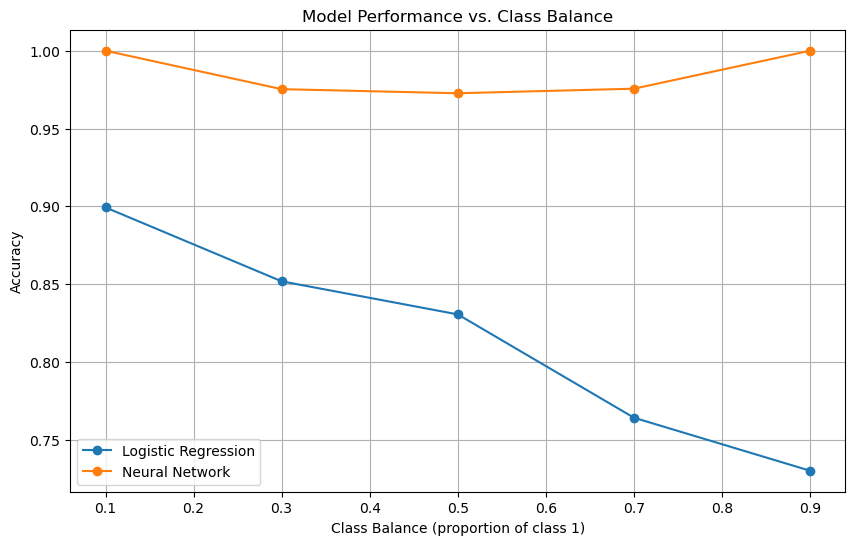

In [38]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score

# Function to generate a dataset with a specified class balance
def generate_balanced_dataset(a, num_points=1000, class_balance=0.5):
    np.random.seed(42)  # For reproducibility
    x = np.random.uniform(-10, 10, num_points)
    y = np.random.uniform(-10, 10, num_points)

    # Calculate the boundary
    y_boundary = a * x**2 + x

    # Classify points based on the boundary
    labels = np.where(y > y_boundary, 1, 0)

    # Adjust class balance by controlling the number of samples per class
    class_1_indices = np.where(labels == 1)[0]
    class_0_indices = np.where(labels == 0)[0]

    # Calculate the target number of samples for each class
    num_class_1 = int(num_points * class_balance)
    num_class_0 = num_points - num_class_1

    # Check if we have enough samples in each class
    num_class_1 = min(num_class_1, len(class_1_indices))  # Ensure we don't select more than available
    num_class_0 = min(num_class_0, len(class_0_indices))  # Ensure we don't select more than available

    # Randomly select samples to match the desired class balance
    selected_class_1 = np.random.choice(class_1_indices, num_class_1, replace=False)
    selected_class_0 = np.random.choice(class_0_indices, num_class_0, replace=False)

    # Combine the selected indices and shuffle them
    selected_indices = np.concatenate([selected_class_1, selected_class_0])
    np.random.shuffle(selected_indices)

    # Create the balanced dataset
    x_balanced = x[selected_indices]
    y_balanced = y[selected_indices]
    labels_balanced = labels[selected_indices]

    return x_balanced, y_balanced, labels_balanced

# Function to evaluate models with different class balances
def evaluate_with_different_balances(a, balances):
    logistic_accuracies = []
    neural_net_accuracies = []

    for balance in balances:
        x, y, labels = generate_balanced_dataset(a=a, num_points=1000, class_balance=balance)
        X = np.column_stack((x, y))  # Combine x and y into the feature matrix
        X_train, X_test, y_train, y_test = train_test_split(X, labels, test_size=0.3, random_state=42)

        # Logistic Regression
        log_reg = LogisticRegression()
        log_reg.fit(X_train, y_train)
        log_reg_predictions = log_reg.predict(X_test)
        log_acc = accuracy_score(y_test, log_reg_predictions)
        logistic_accuracies.append(log_acc)

        # Neural Network
        mlp = MLPClassifier(hidden_layer_sizes=(10,), max_iter=1000, random_state=42)
        mlp.fit(X_train, y_train)
        mlp_predictions = mlp.predict(X_test)
        nn_acc = accuracy_score(y_test, mlp_predictions)
        neural_net_accuracies.append(nn_acc)

        print(f"For class balance = {balance}:")
        print(f"Logistic Regression Accuracy: {log_acc:.4f}")
        print(f"Neural Network Accuracy: {nn_acc:.4f}")
        print()

    return logistic_accuracies, neural_net_accuracies

# List of class balances to evaluate
balances = [0.1, 0.3, 0.5, 0.7, 0.9]

# Run evaluation with different class balances
logistic_accuracies, neural_net_accuracies = evaluate_with_different_balances(a=1, balances=balances)

# Plot results
plt.style.use('default') 
plt.figure(figsize=(10, 6))
plt.plot(balances, logistic_accuracies, 'o-', label='Logistic Regression')
plt.plot(balances, neural_net_accuracies, 'o-', label='Neural Network')
plt.xlabel('Class Balance (proportion of class 1)')
plt.ylabel('Accuracy')
plt.title('Model Performance vs. Class Balance')
plt.legend()
plt.grid(True)
plt.show()


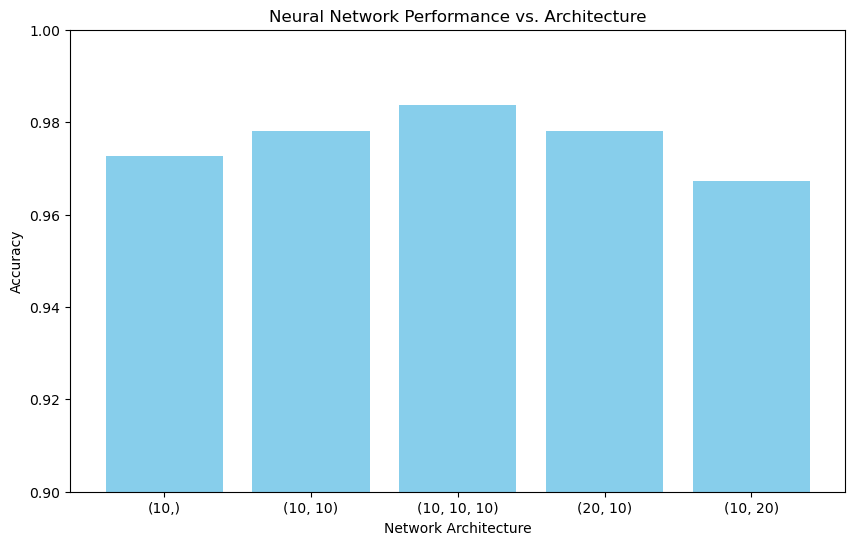

In [40]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score

# Function to generate a balanced dataset
def generate_balanced_dataset(a, num_points=1000, class_balance=0.5):
    np.random.seed(42)  # For reproducibility
    x = np.random.uniform(-10, 10, num_points)
    y = np.random.uniform(-10, 10, num_points)

    # Calculate the boundary
    y_boundary = a * x**2 + x

    # Classify points based on the boundary
    labels = np.where(y > y_boundary, 1, 0)

    # Adjust class balance by controlling the number of samples per class
    class_1_indices = np.where(labels == 1)[0]
    class_0_indices = np.where(labels == 0)[0]

    # Calculate the target number of samples for each class
    num_class_1 = int(num_points * class_balance)
    num_class_0 = num_points - num_class_1

    # Check if we have enough samples in each class
    num_class_1 = min(num_class_1, len(class_1_indices))  # Ensure we don't select more than available
    num_class_0 = min(num_class_0, len(class_0_indices))  # Ensure we don't select more than available

    # Randomly select samples to match the desired class balance
    selected_class_1 = np.random.choice(class_1_indices, num_class_1, replace=False)
    selected_class_0 = np.random.choice(class_0_indices, num_class_0, replace=False)

    # Combine the selected indices and shuffle them
    selected_indices = np.concatenate([selected_class_1, selected_class_0])
    np.random.shuffle(selected_indices)

    # Create the balanced dataset
    x_balanced = x[selected_indices]
    y_balanced = y[selected_indices]
    labels_balanced = labels[selected_indices]

    return x_balanced, y_balanced, labels_balanced

# Function to evaluate models with different network architectures
def evaluate_with_different_layer_counts(a, architectures):
    neural_net_accuracies = []
    architecture_names = []

    # Generate balanced dataset
    x, y, labels = generate_balanced_dataset(a=a, num_points=1000, class_balance=0.5)
    X = np.column_stack((x, y))  # Combine x and y into the feature matrix
    X_train, X_test, y_train, y_test = train_test_split(X, labels, test_size=0.3, random_state=42)

    for arch in architectures:
        # Neural Network with specified architecture
        mlp = MLPClassifier(hidden_layer_sizes=arch, max_iter=1000, random_state=42)
        mlp.fit(X_train, y_train)
        mlp_predictions = mlp.predict(X_test)
        accuracy = accuracy_score(y_test, mlp_predictions)
        neural_net_accuracies.append(accuracy)
        architecture_names.append(str(arch))

    return architecture_names, neural_net_accuracies

# Test different network architectures
architectures = [(10,), (10, 10), (10, 10, 10), (20, 10), (10, 20)]
architecture_names, neural_net_accuracies = evaluate_with_different_layer_counts(a=1, architectures=architectures)

# Plot results
plt.style.use('default')  # Reset to default style with white background
plt.figure(figsize=(10, 6))
plt.bar(architecture_names, neural_net_accuracies, color='skyblue')
plt.xlabel('Network Architecture')
plt.ylabel('Accuracy')
plt.title('Neural Network Performance vs. Architecture')
plt.ylim(0.9, 1.0)  # Adjust as needed to focus on accuracy range
plt.show()
